In [1]:
import math
import numpy as np
import os
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
from tqdm import tqdm

from transformer_prior import GPT
from utils.utils import plot_train_val_losses, reconstruct, return_device, return_photos
from vq_vae import TinnyVQVAE, loss_vq_vae, train



In [2]:
device = return_device()

Device is cuda


In [3]:
PATH_TO_PHOTOS = '../archive/lfw-deepfunneled'

all_photos = return_photos(PATH_TO_PHOTOS)

100%|██████████| 13233/13233 [00:10<00:00, 1241.00it/s]

Photos uploaded: 13233


In [4]:
batch_size = 32

train_photos, val_photos = train_test_split(all_photos, train_size=0.9, shuffle=True)
train_loader = torch.utils.data.DataLoader(train_photos, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(val_photos, batch_size=batch_size)

In [5]:
USE_EMA = False  # True = EMA codebook, False = gradient codebook

N_E = 1024
model = TinnyVQVAE(n_e=N_E, e_dim=8, use_ema=USE_EMA).to(device)

model.eval()
with torch.no_grad():
    sample_batch = next(iter(train_loader)).permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
    z_e, _ = model.encode(sample_batch)  # (BS*H*W, e_dim)
    perm = torch.randperm(z_e.shape[0])[:model.quantize.n_e]
    model.quantize.init_from_data(z_e[perm])
    print('Codebook initialized from data')

train_mse_losses, train_vq_losses, val_mse_losses, val_vq_losses = train(
    model=model,
    n_epochs=200,
    train_loader=train_loader, 
    val_loader=val_loader,
    device=device, 
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3)
)

Codebook initialized from data


100%|██████████| 200/200 [08:09<00:00,  2.45s/it]


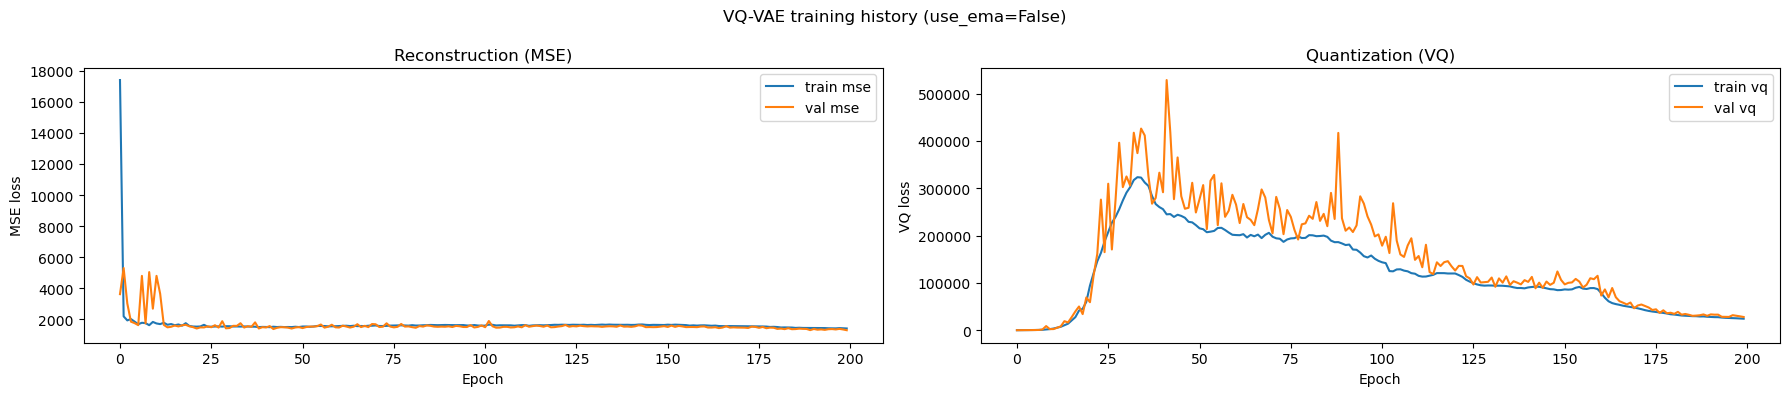

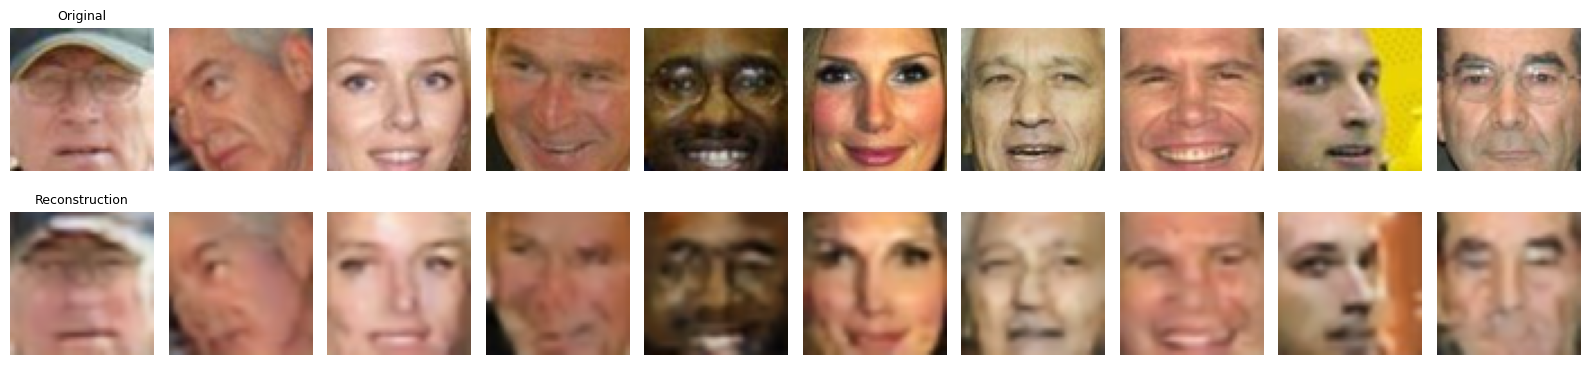

In [6]:
fig, (ax_mse, ax_vq) = plt.subplots(1, 2, figsize=(18, 4))

ax_mse.plot(train_mse_losses, label='train mse')
ax_mse.plot(val_mse_losses, label='val mse')
ax_mse.set_xlabel('Epoch')
ax_mse.set_ylabel('MSE loss')
ax_mse.set_title('Reconstruction (MSE)')
ax_mse.legend()

ax_vq.plot(train_vq_losses, label='train vq')
ax_vq.plot(val_vq_losses, label='val vq')
ax_vq.set_xlabel('Epoch')
ax_vq.set_ylabel('VQ loss')
ax_vq.set_title('Quantization (VQ)')
ax_vq.legend()

fig.suptitle(f"VQ-VAE training history (use_ema={USE_EMA})")
plt.tight_layout()
plt.show()

reconstruct(model, val_loader, device)

This can be explained by the fact that we don't constrain the norm of the codebook vectors, so at some point they start "drifting" apart. However, relative to the encoder vectors, the nearest codebook vectors stay the same — they just end up farther away in space. That's why vq_loss grows while the decoding quality doesn't change and mse_loss stays just as low.

Codebook size: 1024
Codes in use:  21


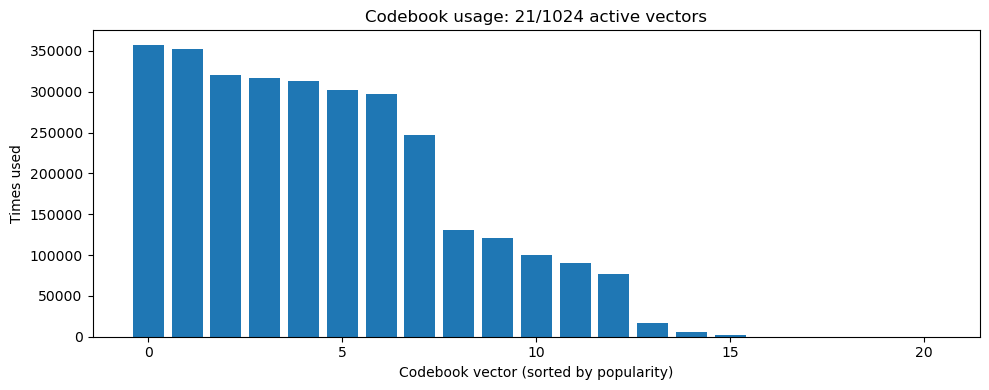

Top-10 codes take 90.4% of all assignments
Median uses: 100045 | max: 357325 | min: 1


In [7]:
def inspect_codebook():
    model.eval()
    all_indices = []
    with torch.no_grad():
        for batch in train_loader:
            batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
            z_e, _ = model.encode(batch)
            indices = model.quantize.get_code_indices(z_e)
            all_indices.append(indices.cpu().numpy())
    all_indices = np.concatenate(all_indices)

    n_e = model.quantize.n_e
    unique, counts = np.unique(all_indices, return_counts=True)
    print(f'Codebook size: {n_e}')
    print(f'Codes in use:  {len(unique)}')

    counts_sorted = np.sort(counts)[::-1]
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(counts_sorted)), counts_sorted)
    plt.xlabel('Codebook vector (sorted by popularity)')
    plt.ylabel('Times used')
    plt.title(f'Codebook usage: {len(unique)}/{n_e} active vectors')
    plt.tight_layout()
    plt.show()

    print(f'Top-10 codes take {counts_sorted[:10].sum() / counts.sum() * 100:.1f}% of all assignments')
    print(f'Median uses: {np.median(counts):.0f} | max: {counts.max()} | min: {counts.min()}')

inspect_codebook()

## EMA codebook

In [8]:
USE_EMA = True

N_E = 1024
model = TinnyVQVAE(n_e=N_E, e_dim=8, use_ema=USE_EMA).to(device)

# Initialize the codebook from real encoder outputs (reduces dead codes).
# init_from_data() handles the variant-specific bookkeeping (EMA also syncs ema_w / cluster_size).

model.eval()
with torch.no_grad():
    sample_batch = next(iter(train_loader)).permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
    z_e, _ = model.encode(sample_batch)  # (BS*H*W, e_dim)
    perm = torch.randperm(z_e.shape[0])[:model.quantize.n_e]
    model.quantize.init_from_data(z_e[perm])
    print('Codebook initialized from data')


train_mse_losses, train_vq_losses, val_mse_losses, val_vq_losses = train(
    model=model,
    n_epochs=100,
    train_loader=train_loader, 
    val_loader=val_loader,
    device=device, 
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3)
)

Codebook initialized from data


100%|██████████| 100/100 [03:59<00:00,  2.39s/it]


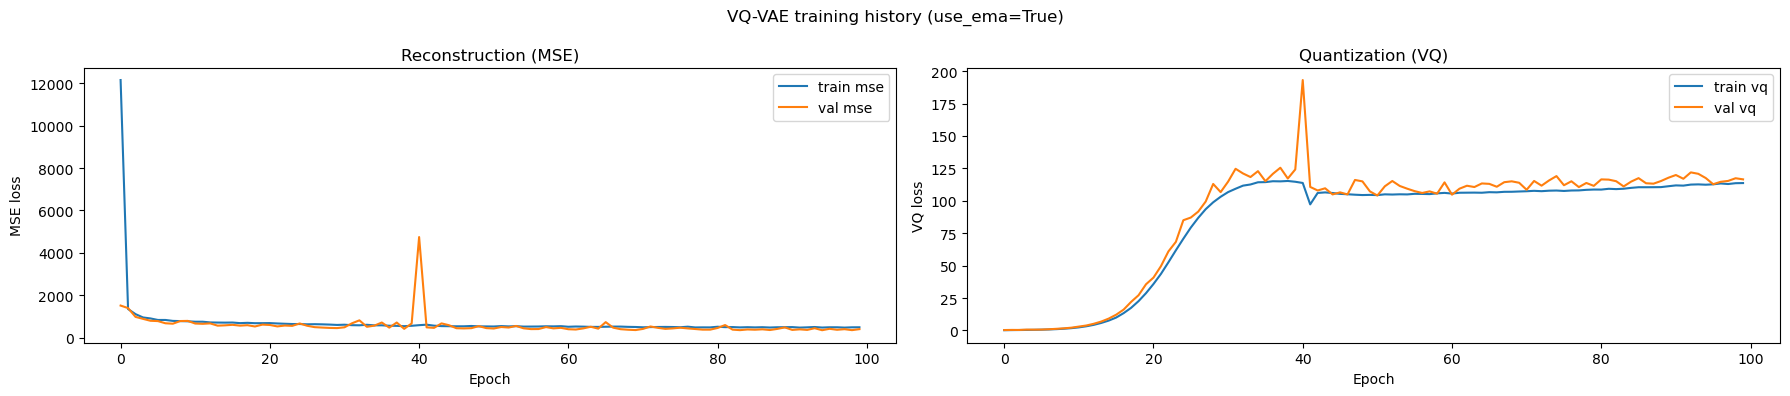

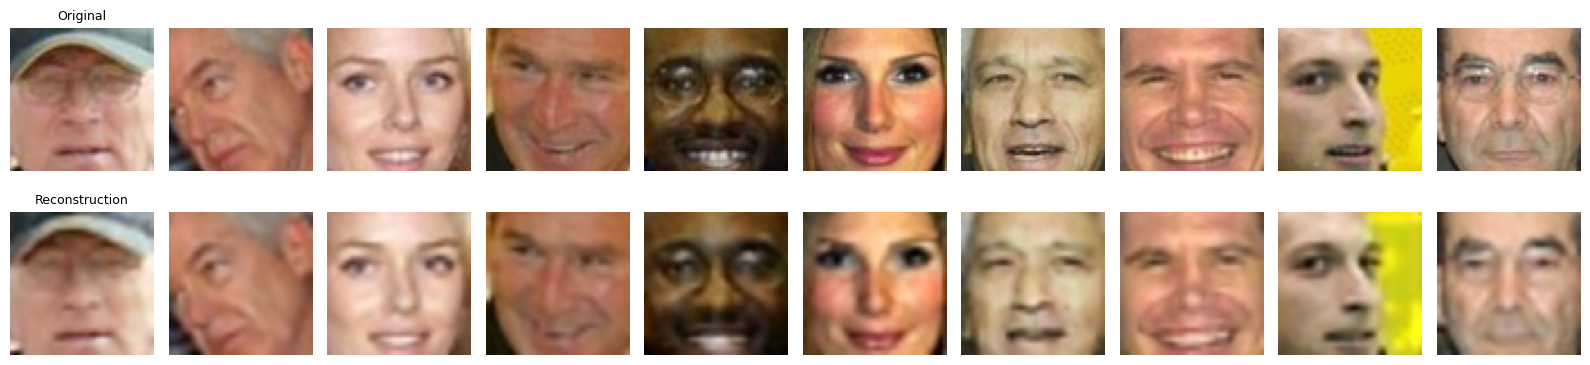

Codebook size: 1024
Codes in use:  1024


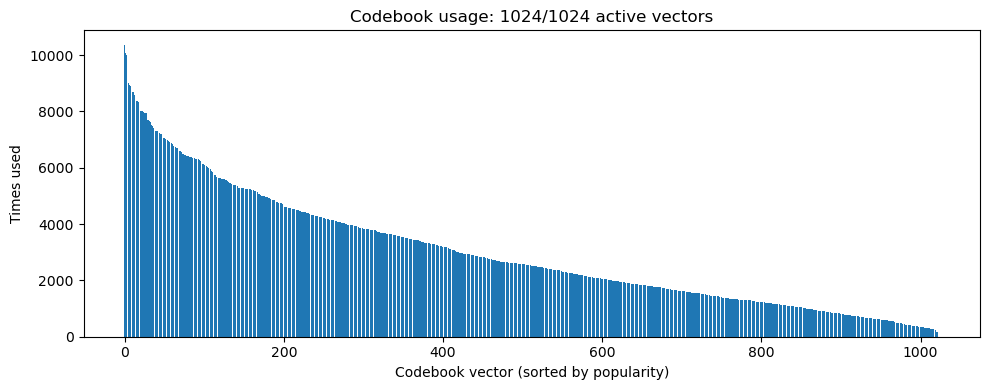

Top-10 codes take 3.1% of all assignments
Median uses: 2519 | max: 10358 | min: 126


In [9]:
fig, (ax_mse, ax_vq) = plt.subplots(1, 2, figsize=(18, 4))

ax_mse.plot(train_mse_losses, label='train mse')
ax_mse.plot(val_mse_losses, label='val mse')
ax_mse.set_xlabel('Epoch')
ax_mse.set_ylabel('MSE loss')
ax_mse.set_title('Reconstruction (MSE)')
ax_mse.legend()

ax_vq.plot(train_vq_losses, label='train vq')
ax_vq.plot(val_vq_losses, label='val vq')
ax_vq.set_xlabel('Epoch')
ax_vq.set_ylabel('VQ loss')
ax_vq.set_title('Quantization (VQ)')
ax_vq.legend()

fig.suptitle(f"VQ-VAE training history (use_ema={USE_EMA})")
plt.tight_layout()
plt.show()

reconstruct(model, val_loader, device)
inspect_codebook()

## Normalized codebook (gradient, no EMA)

L2-normalize the encoder outputs and the codebook before the nearest-neighbour
search, turning it into a cosine (direction-only) match. This removes the codebook
norm drift seen above and usually activates many more codes. Same `N_E=1024` as the
gradient run above, so the codebook-usage plots are directly comparable.

In [10]:
USE_EMA = False
NORMALIZE = True

N_E = 1024
model = TinnyVQVAE(n_e=N_E, e_dim=8, use_ema=USE_EMA, normalize=NORMALIZE).to(device)

model.eval()
with torch.no_grad():
    sample_batch = next(iter(train_loader)).permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
    z_e, _ = model.encode(sample_batch)
    perm = torch.randperm(z_e.shape[0])[:model.quantize.n_e]
    model.quantize.init_from_data(z_e[perm])
    print('Codebook initialized from data')

train_mse_losses, train_vq_losses, val_mse_losses, val_vq_losses = train(
    model=model,
    n_epochs=100,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    optimizer=torch.optim.Adam(model.parameters(), lr=1e-3)
)

Codebook initialized from data


100%|██████████| 100/100 [04:26<00:00,  2.67s/it]


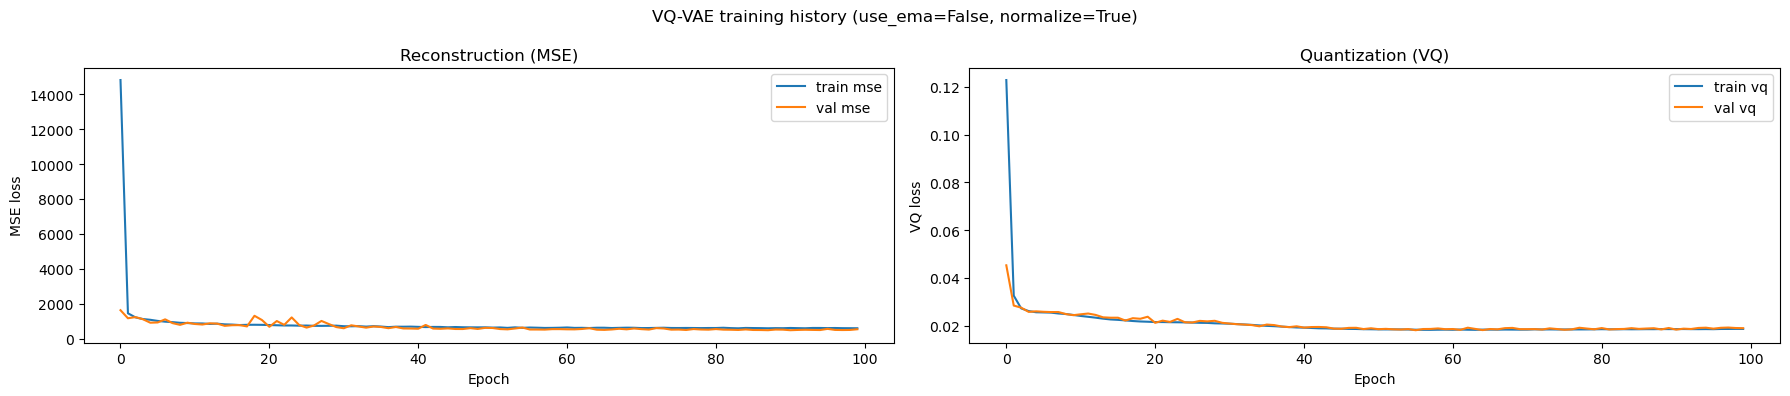

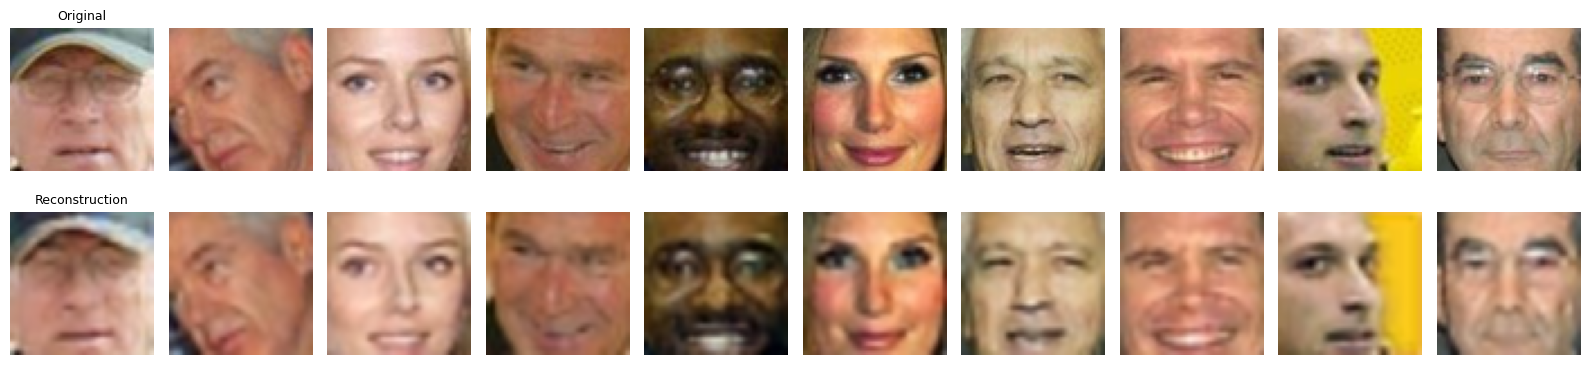

Codebook size: 1024
Codes in use:  1024


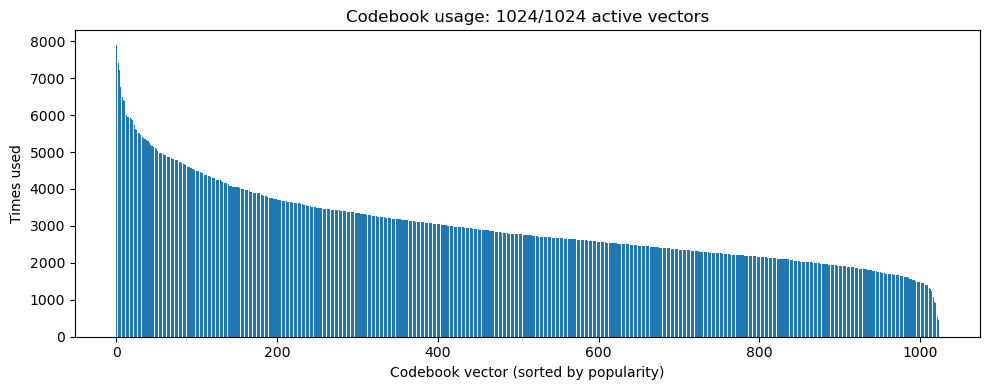

Top-10 codes take 2.3% of all assignments
Median uses: 2758 | max: 7901 | min: 460


In [11]:
fig, (ax_mse, ax_vq) = plt.subplots(1, 2, figsize=(18, 4))

ax_mse.plot(train_mse_losses, label='train mse')
ax_mse.plot(val_mse_losses, label='val mse')
ax_mse.set_xlabel('Epoch'); ax_mse.set_ylabel('MSE loss')
ax_mse.set_title('Reconstruction (MSE)'); ax_mse.legend()

ax_vq.plot(train_vq_losses, label='train vq')
ax_vq.plot(val_vq_losses, label='val vq')
ax_vq.set_xlabel('Epoch'); ax_vq.set_ylabel('VQ loss')
ax_vq.set_title('Quantization (VQ)'); ax_vq.legend()

fig.suptitle(f"VQ-VAE training history (use_ema={USE_EMA}, normalize={NORMALIZE})")
plt.tight_layout()
plt.show()

reconstruct(model, val_loader, device)
inspect_codebook()

## Tokens for the transformer prior

Run every train image through the encoder and record the nearest codebook index at
each of the 16×16 = 256 spatial positions. We need only the indices (the tokens),
not z_q. These per-image index sequences are the training data for the transformer
prior in the next stage.

In [12]:
# get_code_indices honors the model's normalize setting automatically,
# so the extracted tokens match exactly how the model was trained.
model.eval()
targets = []
with torch.no_grad():
    for batch in train_loader:
        batch = batch.permute(0, 3, 1, 2).to(device).to(torch.float32) / 255
        z_e, (B, H, W, C) = model.encode(batch)
        indices = model.quantize.get_code_indices(z_e)  # (B*H*W,)
        targets.append(indices.reshape(B, H * W).cpu().numpy())  # (B, 256)
targets = np.concatenate(targets, axis=0)

print('targets shape:', targets.shape)  # (n_train, 256)
assert targets.shape[1] == 256

targets shape: (11909, 256)


In [13]:
START_TOKEN = model.quantize.n_e  # 1024 when N_E=1024
targets = np.concatenate([np.full((targets.shape[0], 1), START_TOKEN), targets], axis=1)
targets = targets.astype(int)

print('targets.shape:', targets.shape)

targets.shape: (11909, 257)


In [14]:
batch_size = 32

train_idx, val_idx = train_test_split(targets, train_size=0.9, shuffle=True)
train_idx_loader = torch.utils.data.DataLoader(train_idx, batch_size=batch_size, shuffle=True)
val_idx_loader = torch.utils.data.DataLoader(val_idx, batch_size=batch_size)

100%|██████████| 20/20 [08:45<00:00, 26.30s/it]


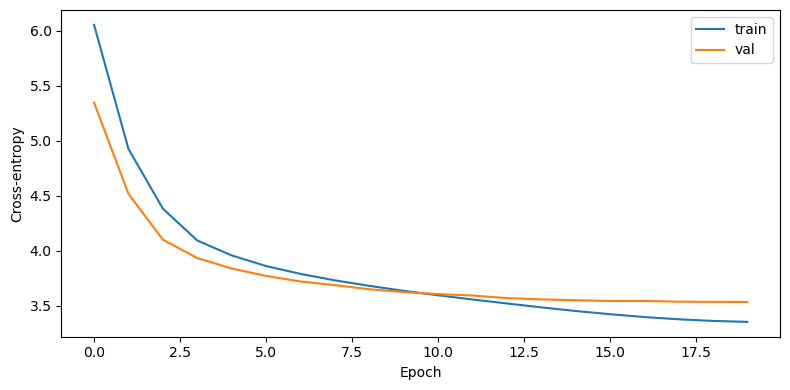

In [15]:
START_TOKEN = model.quantize.n_e

gpt = GPT(
    vocab_size=model.quantize.n_e + 1,  # codes + start token
    block_size=256,  # 16x16 latent = 256 positions
    n_layer=6,
    n_head=8,
    n_embd=384,
    dropout=0.1,
).to(device)

n_epochs = 20
warmup_epochs = 5
base_lr = 3e-4

optimizer = torch.optim.AdamW(gpt.parameters(), lr=base_lr, weight_decay=0.01)

def lr_factor(epoch):
    if epoch < warmup_epochs:
        return (epoch + 1) / warmup_epochs
    progress = (epoch - warmup_epochs) / max(1, n_epochs - warmup_epochs)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_factor)

train_losses, val_losses = [], []
for epoch in tqdm(range(n_epochs)):
    gpt.train()
    ep = []
    for seq in train_idx_loader:
        seq = seq.to(device)
        optimizer.zero_grad()
        logits = gpt(seq[:, :-1])
        loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), seq[:, 1:].reshape(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(gpt.parameters(), 1.0)
        optimizer.step()
        ep.append(loss.item())
    train_losses.append(np.mean(ep))

    gpt.eval()
    ep = []
    with torch.no_grad():
        for seq in val_idx_loader:
            seq = seq.to(device)
            logits = gpt(seq[:, :-1])
            loss = F.cross_entropy(logits.reshape(-1, logits.size(-1)), seq[:, 1:].reshape(-1))
            ep.append(loss.item())
    val_losses.append(np.mean(ep))
    scheduler.step()

plot_train_val_losses(train_losses, val_losses, 'Cross-entropy')

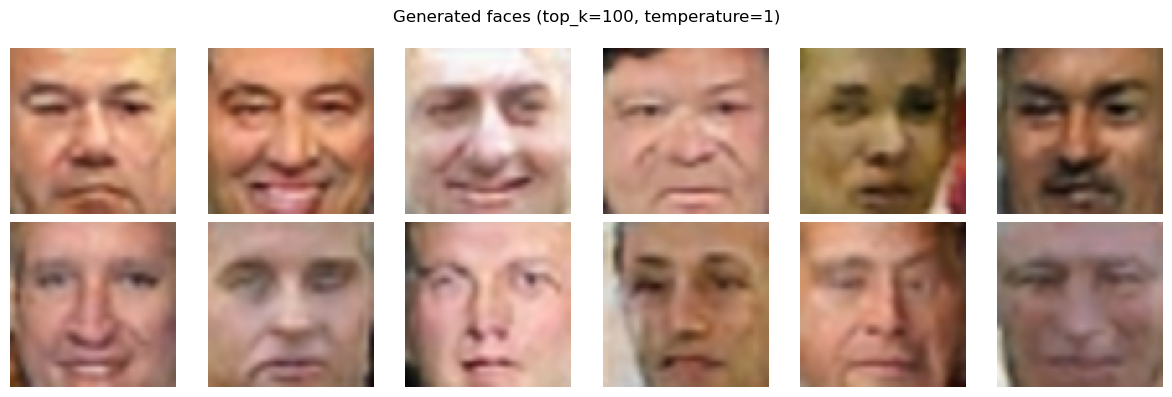

In [22]:
@torch.no_grad()
def sample_faces(n, temperature=1.0, top_k=100, top_p=None):
    gpt.eval(); model.eval()
    start = torch.full((n, 1), START_TOKEN, dtype=torch.long, device=device)
    tokens = gpt.generate(start, max_new_tokens=256, temperature=temperature,
                          top_k=top_k, top_p=top_p, forbidden=[START_TOKEN])[:, 1:]
    side = int(round(tokens.shape[1] ** 0.5))
    z_q = model.quantize.embed_code(tokens.reshape(-1))
    imgs = model.decode(z_q, (n, side, side, model.quantize.e_dim))
    return imgs.permute(0, 2, 3, 1).cpu().numpy()

generated = sample_faces(12, temperature=1.0, top_k=100)
fig, axes = plt.subplots(2, 6, figsize=(12, 4))
for idx, ax in enumerate(axes.flatten()):
    ax.imshow(generated[idx].clip(0, 1)); ax.axis('off')
plt.suptitle('Generated faces (top_k=100, temperature=1)')
plt.tight_layout()
plt.show()

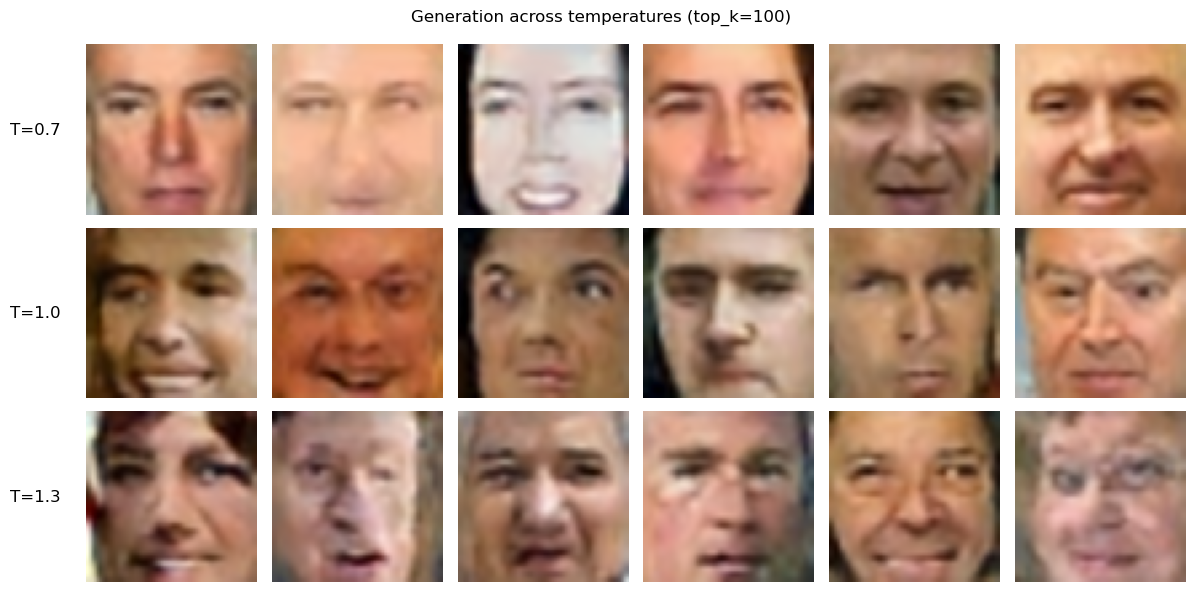

In [24]:
temperatures = [0.7, 1.0, 1.3]
n_cols = 6
fig, axes = plt.subplots(len(temperatures), n_cols, figsize=(2 * n_cols, 2 * len(temperatures)))
for r, tau in enumerate(temperatures):
    faces = sample_faces(n_cols, temperature=tau, top_k=100)
    for c in range(n_cols):
        axes[r, c].imshow(faces[c].clip(0, 1)); axes[r, c].axis('off')
    axes[r, 0].text(-0.15, 0.5, f'T={tau}', transform=axes[r, 0].transAxes,
                    ha='right', va='center', fontsize=12)
fig.suptitle('Generation across temperatures (top_k=100)')
plt.tight_layout()
plt.show()